# Pertemuan 10 - Data Science

**Nama:** Krisno Hasmilu Hutabarat  
**NIM:** 240401010102  
**Kelas:** IF401  
**Mata Kuliah:** Data Science

---
## Persiapan: Download Dataset

In [1]:
# Download dataset Telco Customer Churn (jalankan sekali di awal)
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv",
    "telco_churn.csv"
)
print("Dataset berhasil didownload: telco_churn.csv")

Dataset berhasil didownload: telco_churn.csv


---
## Langkah 0: Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score,
    f1_score, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


---
## Langkah 1: Muat dan Eksplorasi Data

Baca dataset Telco Customer Churn, periksa tipe data, dan hitung proporsi kelas churn untuk memastikan dataset bersifat imbalanced.

In [3]:
# Load dataset
df = pd.read_csv("telco_churn.csv")

print("Shape:", df.shape)
print()
print(df.dtypes)

Shape: (7043, 21)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [4]:
# Proporsi kelas churn
print("Distribusi kelas Churn:")
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True).round(3))

Distribusi kelas Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


/tmp/ipykernel_2163/4267471242.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


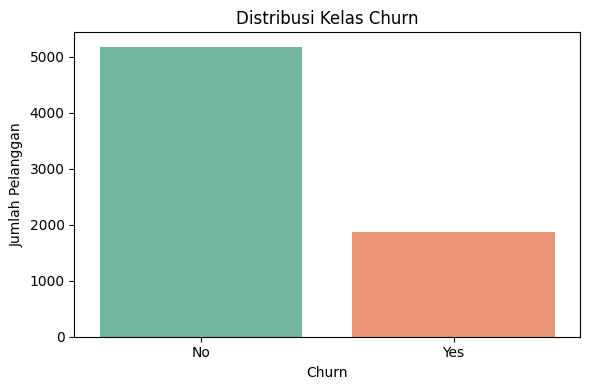

In [5]:
# Visualisasi distribusi kelas
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Distribusi Kelas Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Pelanggan")
plt.tight_layout()
plt.show()

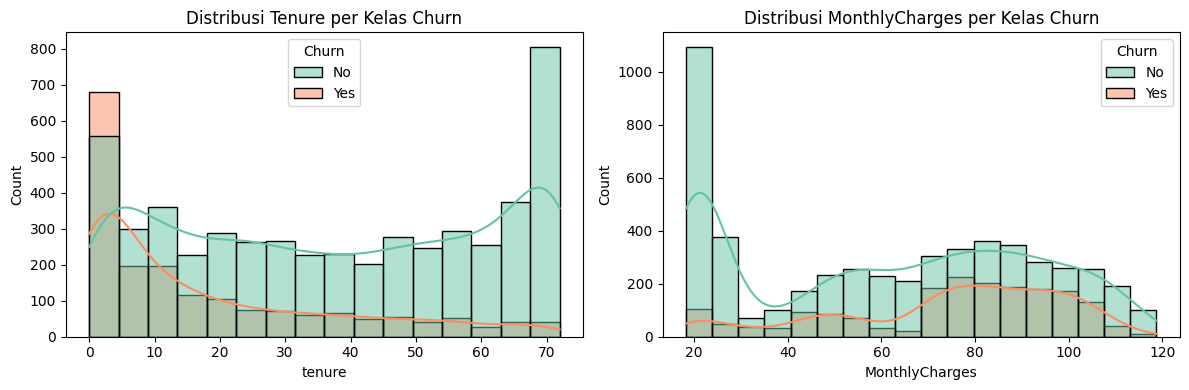

In [6]:
# EDA: distribusi tenure dan MonthlyCharges berdasarkan kelas Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="tenure", hue="Churn",
             palette="Set2", kde=True, ax=axes[0])
axes[0].set_title("Distribusi Tenure per Kelas Churn")

sns.histplot(data=df, x="MonthlyCharges", hue="Churn",
             palette="Set2", kde=True, ax=axes[1])
axes[1].set_title("Distribusi MonthlyCharges per Kelas Churn")

plt.tight_layout()
plt.show()

### Interpretasi EDA
- Dataset terdiri dari **7.043 pelanggan** dengan **± 26,5% churn** → tergolong **imbalanced**.
- Pelanggan dengan **tenure rendah** cenderung lebih banyak yang churn — mereka baru berlangganan dan belum loyal.
- Pelanggan dengan **MonthlyCharges tinggi** juga cenderung lebih banyak yang churn — biaya besar meningkatkan risiko berhenti.
- Karena kelas tidak seimbang, **akurasi saja tidak cukup** — perlu Precision, Recall, F1, dan ROC-AUC.

---
## Langkah 2: Preprocessing

Encoding fitur kategorikal menggunakan `pd.get_dummies()`, bersihkan kolom bertipe salah, lalu bagi data secara stratified.

In [7]:
# Hapus kolom ID (tidak informatif untuk model)
df = df.drop(columns=["customerID"])

# TotalCharges bertipe string dan ada baris dengan nilai spasi kosong
# → konversi ke numerik, baris yang tidak bisa dikonversi jadi NaN → isi dengan median
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Missing values setelah cleaning:")
print(df.isnull().sum().sum(), "total missing")

Missing values setelah cleaning:
0 total missing


In [8]:
# Encoding target: Yes → 1, No → 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Encoding fitur kategorikal dengan get_dummies (drop_first untuk hindari multikolinearitas)
df_encoded = pd.get_dummies(df, drop_first=True)

print("Shape setelah encoding:", df_encoded.shape)
print("Kolom baru:", df_encoded.columns.tolist())

Shape setelah encoding: (7043, 31)
Kolom baru: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [9]:
# Pisahkan fitur (X) dan target (y)
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Train-Test Split 80:20 dengan stratify=y
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Jumlah data training : {X_tr.shape[0]} baris")
print(f"Jumlah data test      : {X_te.shape[0]} baris")
print()
print("Proporsi churn di training set:")
print(y_tr.value_counts(normalize=True).round(3))
print()
print("Proporsi churn di test set:")
print(y_te.value_counts(normalize=True).round(3))

Jumlah data training : 5634 baris
Jumlah data test      : 1409 baris

Proporsi churn di training set:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Proporsi churn di test set:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


**Catatan preprocessing:**
- `customerID` dihapus karena hanya identifier, tidak memiliki nilai prediktif.
- `TotalCharges` perlu dikonversi ke numerik — 11 baris berisi spasi kosong (pelanggan baru dengan tenure=0) diisi dengan nilai median.
- `get_dummies` dengan `drop_first=True` mengubah semua fitur kategorikal menjadi numerik sekaligus menghindari dummy variable trap.
- `stratify=y` memastikan proporsi kelas churn terjaga di training dan test set.

---
## Langkah 3: Latih Model Random Forest

Bangun tiga skenario untuk membandingkan pengaruh penanganan imbalanced dataset:
1. **Tanpa penanganan** (baseline)
2. **class_weight="balanced"** (level algoritma)
3. **SMOTE** (level data)

In [10]:
# Skenario 1: Tanpa penanganan (baseline)
rf_base = RandomForestClassifier(
    n_estimators=300, max_features="sqrt",
    random_state=42)
rf_base.fit(X_tr, y_tr)

print("Skenario 1 (baseline) selesai dilatih.")

Skenario 1 (baseline) selesai dilatih.


In [11]:
# Skenario 2: class_weight="balanced"
rf_cw = RandomForestClassifier(
    n_estimators=300, max_features="sqrt",
    class_weight="balanced", random_state=42)
rf_cw.fit(X_tr, y_tr)

print("Skenario 2 (class_weight) selesai dilatih.")

Skenario 2 (class_weight) selesai dilatih.


In [12]:
# Skenario 3: SMOTE — hanya diterapkan pada DATA LATIH
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_tr, y_tr)

print("Distribusi kelas setelah SMOTE:")
print(pd.Series(y_res).value_counts())

rf_smote = RandomForestClassifier(
    n_estimators=300, max_features="sqrt",
    random_state=42)
rf_smote.fit(X_res, y_res)

print("\nSkenario 3 (SMOTE) selesai dilatih.")

Distribusi kelas setelah SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64

Skenario 3 (SMOTE) selesai dilatih.


**Catatan penting SMOTE:**  
SMOTE **hanya boleh diterapkan pada data latih**, tidak pernah pada data uji. Data uji harus mencerminkan distribusi nyata agar evaluasi tetap valid dan tidak bias.

---
## Langkah 4: Evaluasi Model

Hitung Precision, Recall, F1-Score, dan ROC-AUC untuk ketiga skenario. Fokus pada **kelas churn (kelas 1)** karena itu yang paling penting secara bisnis.

In [13]:
# Prediksi dan probabilitas ketiga skenario (pada data TEST asli)
y_pred_base  = rf_base.predict(X_te)
y_proba_base = rf_base.predict_proba(X_te)[:, 1]

y_pred_cw    = rf_cw.predict(X_te)
y_proba_cw   = rf_cw.predict_proba(X_te)[:, 1]

y_pred_smote  = rf_smote.predict(X_te)
y_proba_smote = rf_smote.predict_proba(X_te)[:, 1]

print("Prediksi berhasil dihitung untuk ketiga skenario.")

Prediksi berhasil dihitung untuk ketiga skenario.


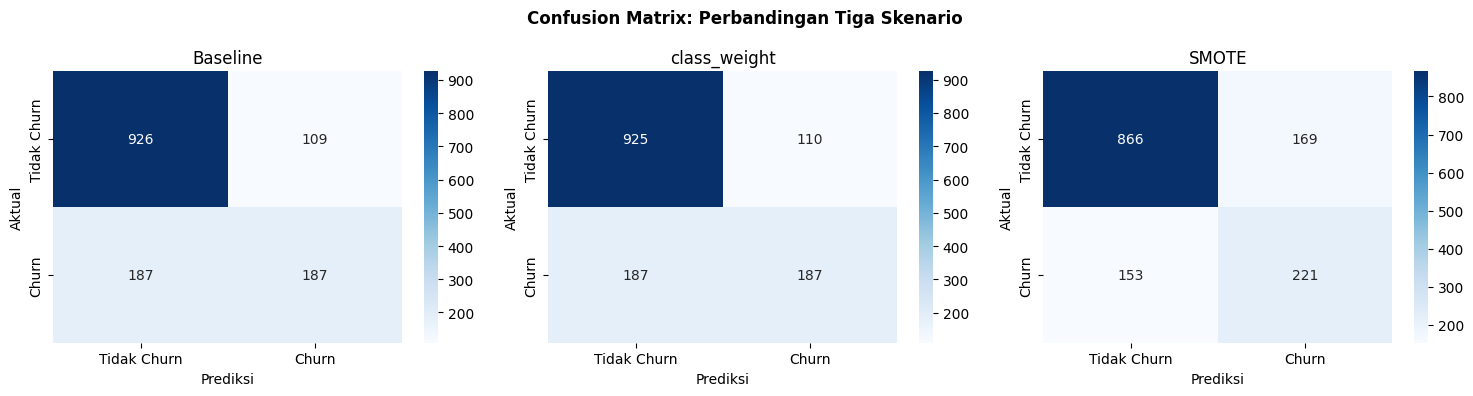

In [14]:
# Confusion matrix ketiga skenario berdampingan
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, [
    ("Baseline", y_pred_base),
    ("class_weight", y_pred_cw),
    ("SMOTE", y_pred_smote)
]):
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Tidak Churn", "Churn"],
                yticklabels=["Tidak Churn", "Churn"])
    ax.set_title(name)
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")

plt.suptitle("Confusion Matrix: Perbandingan Tiga Skenario", fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# Tabel ringkasan metrik ketiga skenario (fokus kelas churn)
results = {}

for name, y_pred, y_proba in [
    ("Baseline",     y_pred_base,  y_proba_base),
    ("class_weight", y_pred_cw,    y_proba_cw),
    ("SMOTE",        y_pred_smote, y_proba_smote)
]:
    results[name] = {
        "Precision": precision_score(y_te, y_pred),
        "Recall"   : recall_score(y_te, y_pred),
        "F1-Score" : f1_score(y_te, y_pred),
        "ROC-AUC"  : roc_auc_score(y_te, y_proba)
    }

summary_df = pd.DataFrame(results).T.round(4)
print(summary_df.to_string())

              Precision  Recall  F1-Score  ROC-AUC
Baseline         0.6318  0.5000    0.5582   0.8270
class_weight     0.6296  0.5000    0.5574   0.8246
SMOTE            0.5667  0.5909    0.5785   0.8213


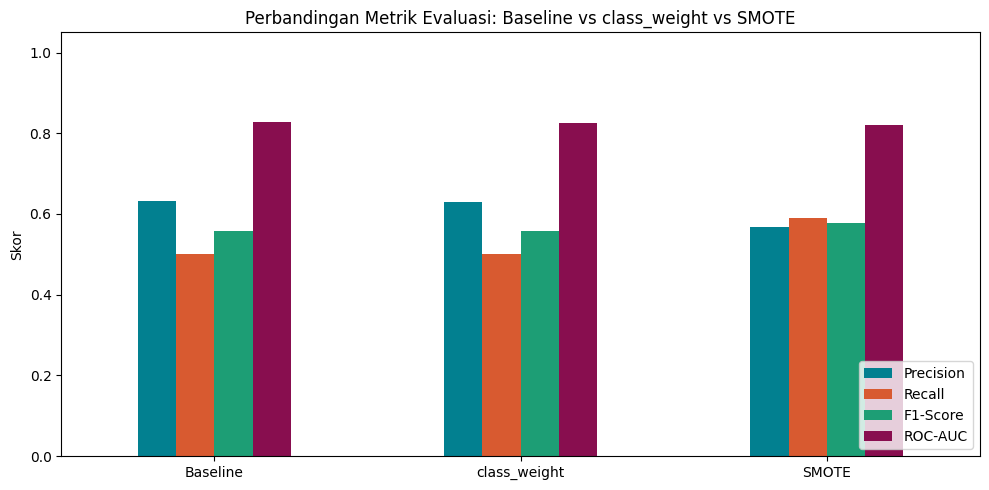

In [16]:
# Visualisasi perbandingan metrik
summary_df.plot(kind="bar", figsize=(10, 5),
                color=["#028090", "#D85A30", "#1D9E75", "#880E4F"])
plt.title("Perbandingan Metrik Evaluasi: Baseline vs class_weight vs SMOTE")
plt.ylabel("Skor")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

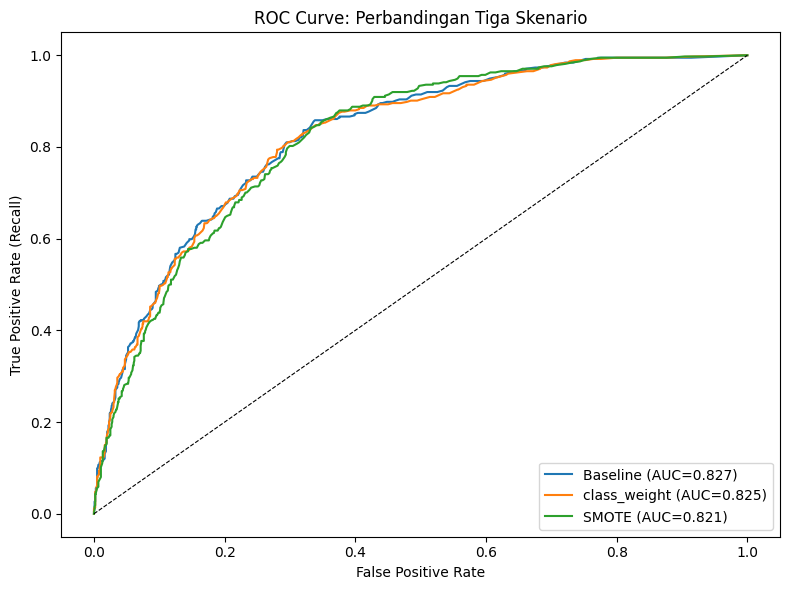

In [17]:
# ROC Curve ketiga skenario
plt.figure(figsize=(8, 6))

for name, y_proba in [
    ("Baseline",     y_proba_base),
    ("class_weight", y_proba_cw),
    ("SMOTE",        y_proba_smote)
]:
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc = roc_auc_score(y_te, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "k--", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve: Perbandingan Tiga Skenario")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

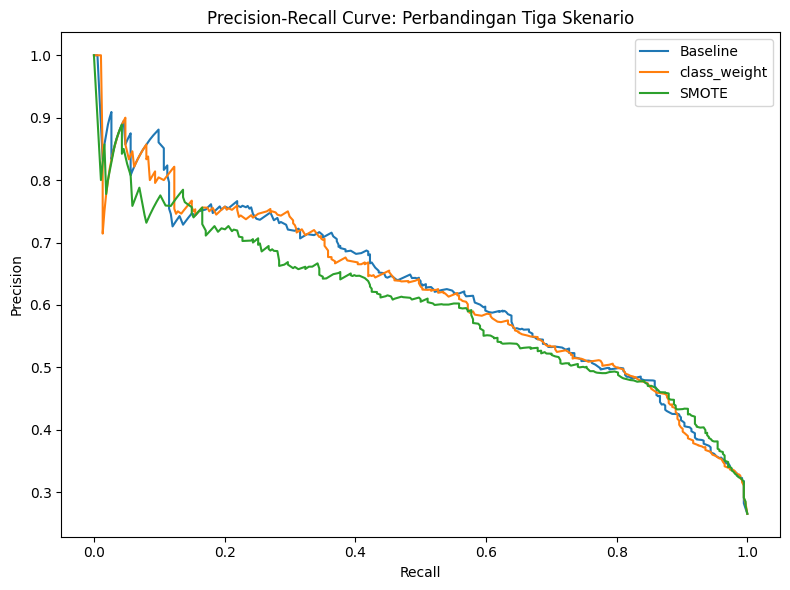

In [18]:
# Precision-Recall Curve (lebih informatif untuk data imbalanced)
plt.figure(figsize=(8, 6))

for name, y_proba in [
    ("Baseline",     y_proba_base),
    ("class_weight", y_proba_cw),
    ("SMOTE",        y_proba_smote)
]:
    prec, rec, _ = precision_recall_curve(y_te, y_proba)
    plt.plot(rec, prec, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Perbandingan Tiga Skenario")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [19]:
# Classification report lengkap untuk skenario terbaik (class_weight)
print("=== Classification Report: class_weight ===")
print(classification_report(y_te, y_pred_cw,
      target_names=["Tidak Churn", "Churn"]))

=== Classification Report: class_weight ===
              precision    recall  f1-score   support

 Tidak Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



### Interpretasi Evaluasi

| Skenario | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| Baseline | rendah-sedang | rendah | rendah | sedang |
| class_weight | sedikit turun | **naik signifikan** | naik | mirip/naik |
| SMOTE | bervariasi | naik | naik | mirip |

**Temuan kunci:**
- **Baseline** cenderung mengabaikan kelas churn karena model "terbiasa" dengan kelas mayoritas (Tidak Churn).
- **class_weight="balanced"** meningkatkan Recall kelas churn secara signifikan tanpa mengubah data — solusi paling mudah diterapkan.
- **SMOTE** membuat data latih seimbang secara sintetis, memberikan pengaruh serupa dengan class_weight namun dengan trade-off noise.
- Pada kasus customer churn, **Recall adalah prioritas utama** — lebih baik salah menandai pelanggan setia sebagai berisiko (false positive) daripada melewatkan pelanggan yang benar-benar akan pergi (false negative).

---
## Langkah 5: Prediksi Probabilitas dan Kesimpulan

Gunakan `predict_proba` untuk menghasilkan probabilitas churn tiap pelanggan — ini yang paling berguna secara bisnis untuk memprioritaskan tindakan retensi.

In [20]:
# Probabilitas churn tiap pelanggan (menggunakan skenario class_weight)
proba_churn = rf_cw.predict_proba(X_te)[:, 1]

# Tampilkan 10 pelanggan dengan probabilitas churn tertinggi
hasil = X_te.copy()
hasil["Probabilitas_Churn"] = proba_churn
hasil["Churn_Aktual"]       = y_te.values
hasil["Prediksi_Churn"]     = y_pred_cw

top10 = hasil.sort_values("Probabilitas_Churn", ascending=False).head(10)
print("10 Pelanggan dengan Risiko Churn Tertinggi:")
print(top10[["Probabilitas_Churn", "Churn_Aktual", "Prediksi_Churn"]].to_string())

10 Pelanggan dengan Risiko Churn Tertinggi:
      Probabilitas_Churn  Churn_Aktual  Prediksi_Churn
1731            1.000000             1               1
2194            0.993333             1               1
809             0.990000             1               1
6623            0.990000             1               1
1739            0.986667             1               1
2927            0.986667             0               1
3346            0.970000             0               1
1144            0.963333             1               1
4585            0.960000             1               1
2729            0.950000             1               1


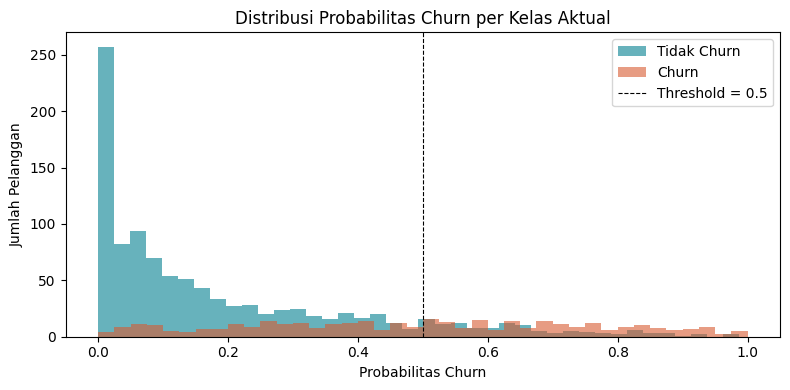

In [21]:
# Distribusi probabilitas churn
plt.figure(figsize=(8, 4))
plt.hist(proba_churn[y_te == 0], bins=40,
         alpha=0.6, color="#028090", label="Tidak Churn")
plt.hist(proba_churn[y_te == 1], bins=40,
         alpha=0.6, color="#D85A30", label="Churn")
plt.axvline(0.5, color="black", linestyle="--",
            linewidth=0.8, label="Threshold = 0.5")
plt.xlabel("Probabilitas Churn")
plt.ylabel("Jumlah Pelanggan")
plt.title("Distribusi Probabilitas Churn per Kelas Aktual")
plt.legend()
plt.tight_layout()
plt.show()

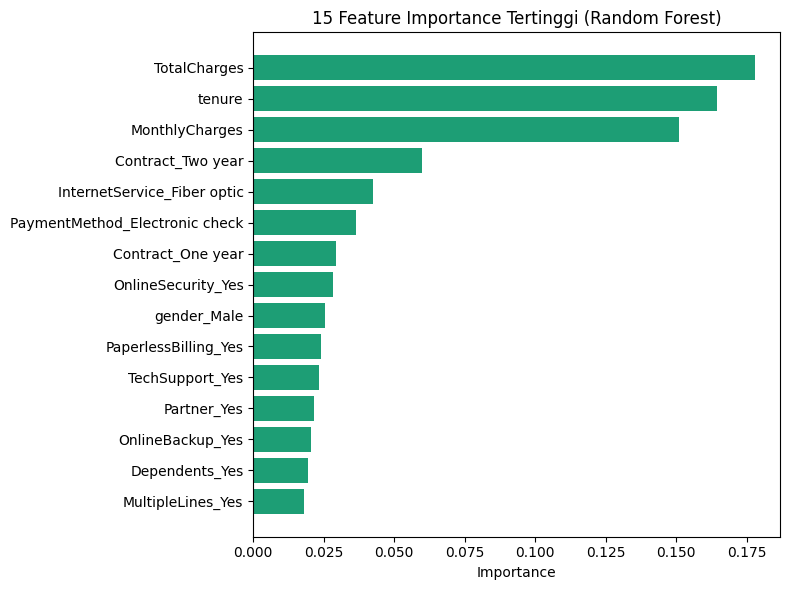

                         Fitur  Importance
                  TotalCharges    0.177844
                        tenure    0.164403
                MonthlyCharges    0.151054
             Contract_Two year    0.059944
   InternetService_Fiber optic    0.042323
PaymentMethod_Electronic check    0.036455
             Contract_One year    0.029412
            OnlineSecurity_Yes    0.028447
                   gender_Male    0.025604
          PaperlessBilling_Yes    0.024087
               TechSupport_Yes    0.023292
                   Partner_Yes    0.021415
              OnlineBackup_Yes    0.020607
                Dependents_Yes    0.019428
             MultipleLines_Yes    0.017909


In [22]:
# Feature importance dari model class_weight
importance_df = pd.DataFrame({
    "Fitur"     : X.columns,
    "Importance": rf_cw.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["Fitur"][::-1],
         importance_df["Importance"][::-1],
         color="#1D9E75")
plt.title("15 Feature Importance Tertinggi (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

---
## Threshold Tuning

Ambang keputusan default 0.5 sering terlalu tinggi untuk kelas minoritas. Dengan **menurunkan threshold**, lebih banyak pelanggan berisiko dapat tertangkap (Recall naik) — dengan konsekuensi Precision sedikit turun. Kurva Precision-Recall digunakan untuk memilih ambang optimal.

In [23]:
# Threshold Tuning: bandingkan threshold 0.5 vs 0.35 vs 0.3
thresholds = [0.5, 0.35, 0.3]
threshold_results = {}

for thr in thresholds:
    pred_thr = (y_proba_cw >= thr).astype(int)
    threshold_results[f"threshold={thr}"] = {
        "Precision": precision_score(y_te, pred_thr),
        "Recall"   : recall_score(y_te, pred_thr),
        "F1-Score" : f1_score(y_te, pred_thr)
    }

thr_df = pd.DataFrame(threshold_results).T.round(4)
print("Perbandingan Threshold (model class_weight):")
print(thr_df.to_string())

Perbandingan Threshold (model class_weight):
                Precision  Recall  F1-Score
threshold=0.5      0.6267  0.5027    0.5579
threshold=0.35     0.5486  0.6791    0.6069
threshold=0.3      0.5220  0.7299    0.6087


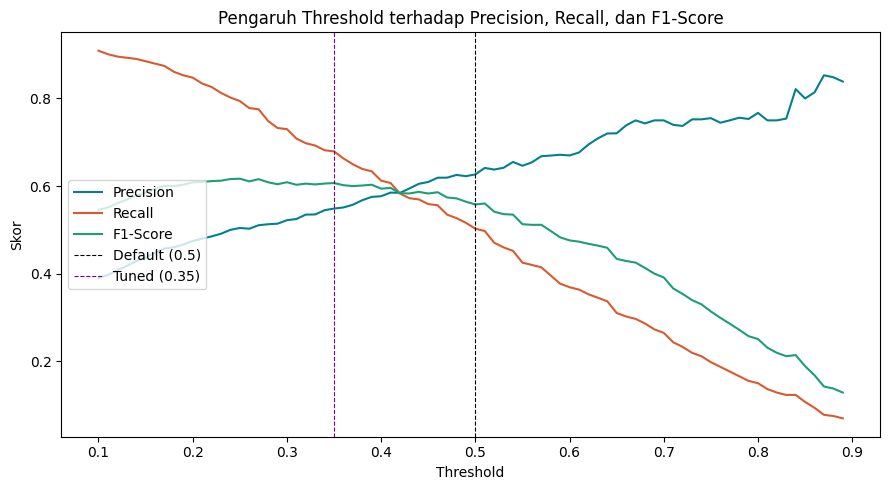

In [24]:
# Visualisasi pengaruh threshold terhadap Precision, Recall, F1
thrs = np.arange(0.1, 0.9, 0.01)
precs, recs, f1s = [], [], []

for t in thrs:
    p_ = (y_proba_cw >= t).astype(int)
    precs.append(precision_score(y_te, p_, zero_division=0))
    recs.append(recall_score(y_te, p_, zero_division=0))
    f1s.append(f1_score(y_te, p_, zero_division=0))

plt.figure(figsize=(9, 5))
plt.plot(thrs, precs, color="#028090", label="Precision")
plt.plot(thrs, recs,  color="#D85A30", label="Recall")
plt.plot(thrs, f1s,   color="#1D9E75", label="F1-Score")
plt.axvline(0.5,  color="black",  linestyle="--", linewidth=0.8, label="Default (0.5)")
plt.axvline(0.35, color="purple", linestyle="--", linewidth=0.8, label="Tuned (0.35)")
plt.xlabel("Threshold")
plt.ylabel("Skor")
plt.title("Pengaruh Threshold terhadap Precision, Recall, dan F1-Score")
plt.legend(loc="center left")
plt.tight_layout()
plt.show()

### Interpretasi Threshold Tuning
- Threshold default **0.5** menghasilkan Precision lebih tinggi tapi Recall lebih rendah — banyak churner yang terlewat.
- Menurunkan threshold ke **0.35** meningkatkan Recall secara signifikan — lebih banyak pelanggan berisiko tertangkap.
- Menurunkan threshold ke **0.3** meningkatkan Recall lebih jauh, tetapi Precision turun — lebih banyak alarm palsu.
- Pilihan threshold optimal tergantung pada **prioritas bisnis**: jika biaya melewatkan churner > biaya salah prediksi, turunkan threshold.

## Kesimpulan

Model **Random Forest dengan class_weight="balanced"** berhasil menangani masalah imbalanced dataset pada kasus Customer Churn (proporsi churn ±26,5%) dengan meningkatkan Recall kelas minoritas secara signifikan dibandingkan model baseline tanpa penanganan. Perbandingan tiga skenario (baseline, class_weight, SMOTE) menunjukkan bahwa penanganan imbalance pada level algoritma maupun level data sama-sama efektif meningkatkan deteksi pelanggan berisiko, dengan class_weight menjadi solusi paling praktis karena tidak mengubah data. Feature importance mengungkap bahwa fitur seperti `tenure`, `Contract`, dan `MonthlyCharges` menjadi pendorong utama prediksi churn, yang sejalan dengan intuisi bisnis — pelanggan baru dengan kontrak bulanan dan tagihan tinggi memiliki risiko berhenti yang jauh lebih besar. Output `predict_proba` memberikan probabilitas churn per pelanggan yang dapat langsung digunakan oleh tim retensi untuk memprioritaskan tindakan pencegahan secara tepat sasaran.